# Practice: Pandas Fundamentals

In this practice, we will review pandas fundamentals.

1) load in necessary modules

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

2) read in the files at 
``https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_no2.csv'', make sure to parse dates

In [27]:
air_quality = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_no2.csv',parse_dates=True)
air_quality.head()

,datetime,station_antwerp,station_paris,station_london
0,2019-05-07 02:00:00,NaN,NaN,23.0
1,2019-05-07 03:00:00,50.5,25.0,19.0
2,2019-05-07 04:00:00,45.0,27.7,19.0
3,2019-05-07 05:00:00,NaN,50.4,16.0
4,2019-05-07 06:00:00,NaN,61.9,NaN


3) Quick visual plot check using .plot()

<Axes: >

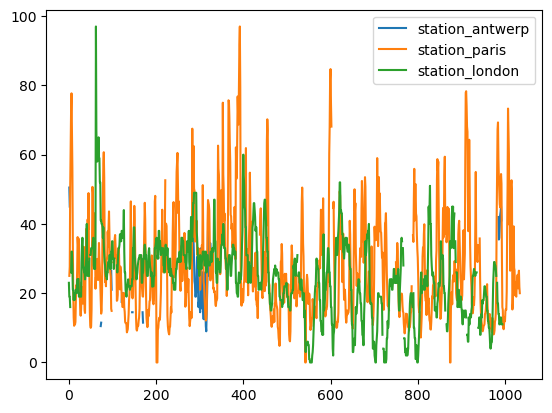

In [29]:
air_quality.plot()

4) Only plot data from Paris now

<Axes: >

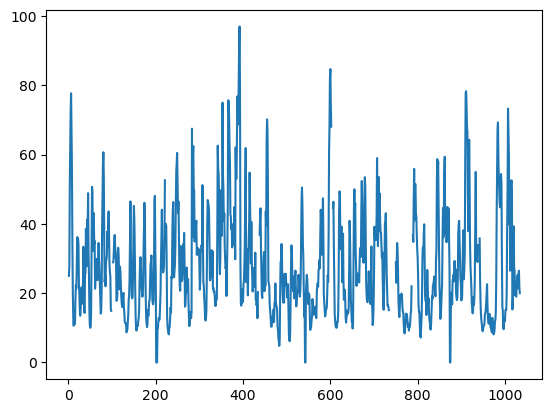

In [30]:
air_quality["station_paris"].plot()

5) Compare Paris and London NO2 using a scatter plot

<Axes: xlabel='station_london', ylabel='station_paris'>

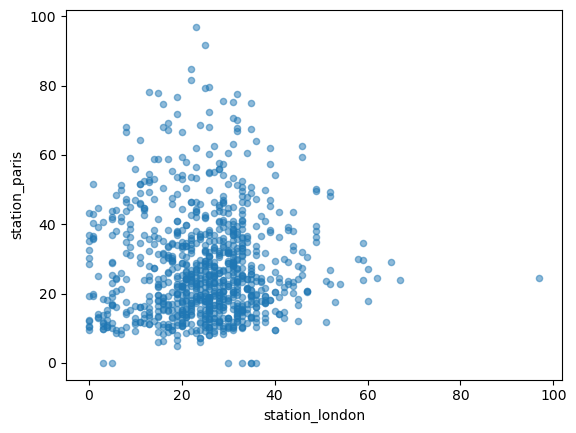

In [32]:
air_quality.plot.scatter(x="station_london", y="station_paris", alpha=0.5)

6) Now plot each column as a separate subplot

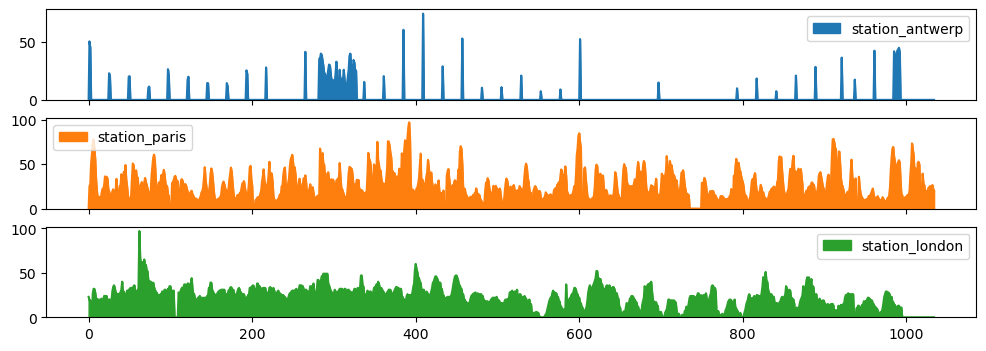

In [33]:
axs = air_quality.plot.area(figsize=(12, 4), subplots=True)

7) Now take one of these figures and make it pretty

8) Now read in the files at 
``https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_no2_long.csv''


In [23]:
air_quality = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_no2_long.csv')
air_quality.head()

,city,country,date.utc,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


9) Read it in again with proper datatime parsing

In [36]:
air_quality = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_no2_long.csv',parse_dates=["date.utc"])

air_quality.head()

,city,country,date.utc,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


10) What is the start date and end date we are using?  What is the length of the time series?

In [37]:
air_quality["date.utc"].min(), air_quality["date.utc"].max()
air_quality["date.utc"].max() - air_quality["date.utc"].min()

Timedelta('44 days 23:00:00')

11) I want to add a new column to the DataFrame containing only the month of the measurement

In [38]:
air_quality["month"] = air_quality["date.utc"].dt.month
air_quality.head()

,city,country,date.utc,location,parameter,value,unit,month
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,6
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,6
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,6
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,6
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,6


12) Calculate the average NO2 concentration for each day of the week for each of the measurement locations.

In [39]:
air_quality.groupby(
    [air_quality["date.utc"].dt.weekday, "location"])["value"].mean()

date.utc  location          
0         BETR801               27.875000
          FR04014               24.856250
          London Westminster    23.969697
1         BETR801               22.214286
          FR04014               30.999359
          London Westminster    24.885714
2         BETR801               21.125000
          FR04014               29.165753
          London Westminster    23.460432
3         BETR801               27.500000
          FR04014               28.600690
          London Westminster    24.780142
4         BETR801               28.400000
          FR04014               31.617986
          London Westminster    26.446809
5         BETR801               33.500000
          FR04014               25.266154
          London Westminster    24.977612
6         BETR801               21.896552
          FR04014               23.274306
          London Westminster    24.859155
Name: value, dtype: float64

13) Plot the typical NO2 pattern during the day of our time series of all stations together. In other words, what is the average value for each hour of the day?



<Axes: xlabel='date.utc'>

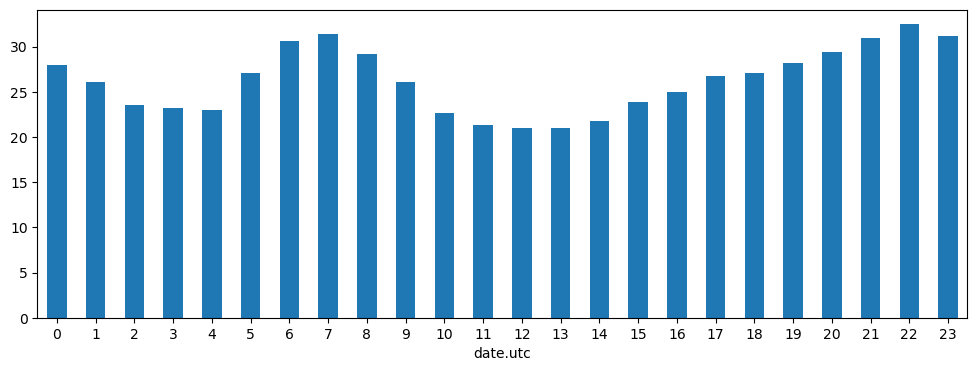

In [45]:
fig, axs = plt.subplots(figsize=(12, 4))
air_quality.groupby(air_quality["date.utc"].dt.hour)["value"].mean().plot(
    kind='bar', rot=0, ax=axs)

We pivot the data to make date.utc an index:

In [49]:
no_2 = air_quality.pivot(index="date.utc", columns="location", values="value")

14) Using indexing of the date, Create a plot of the NO2 values in the different stations from May 20th till the end of May 21st.

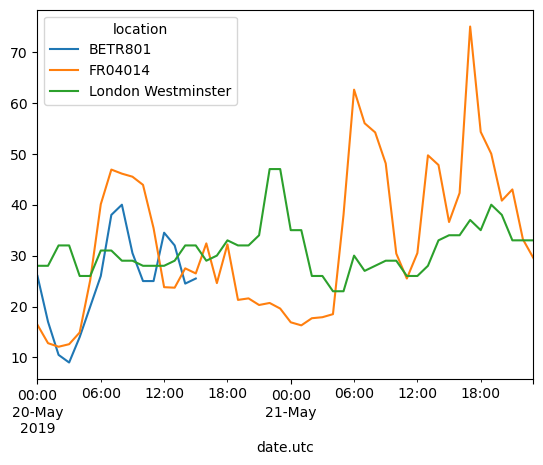

In [50]:
no_2["2019-05-20":"2019-05-21"].plot();
